In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from config import PROCESSED_DATA_DIR

from src.graph.eda import SAMLDGraphEDA

In [2]:
### initialize validation graph EDA
validation_snapshot_dir = PROCESSED_DATA_DIR / 'graph' / 'validation'

# create graph EDA instance
graph_eda = SAMLDGraphEDA(
    snapshot_dir = validation_snapshot_dir
)

print(
    f'Validation snapshot: {validation_snapshot_dir}'
)

Validation snapshot: /Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/validation


In [3]:
### validation summary
validation_table_summary = graph_eda.get_table_summary()

display(validation_table_summary)

table,row_count
str,u64
"""nodes""",736925
"""edges""",761365
"""seeds""",5737
"""targets""",958


In [4]:
### validation ranking population
validation_supervision_summary = graph_eda.get_supervision_summary()

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1
):
    display(validation_supervision_summary)

node_count,seed_count,candidate_count,seed_share,future_suspicious_account_count,previously_known_future_account_count,new_future_suspicious_account_count,rankable_target_count,unrankable_target_count,rankable_target_coverage,candidate_positive_rate
u64,u64,u64,f64,u64,u64,u64,u64,u64,f64,f64
736925,5737,731188,0.007785,958,166,792,678,114,0.856061,0.000927


**Discussion - graph size and validation population**

The historical validation graph contains **736k** accounts and **761k** aggregated directed account pairs. The edge-to-node ratio is therefore only about **1.03**, which already suggests a sparse network

The ranking population is deliberately different from the full node population:
- The **5737 historical suspicious accounts** are PageRank seeds and represent **0.78%** of all historical seeds. They must be excluded from the candidate ranking since they are already known
- The remaining **731k accounts** from the candidate population
- of the **958 accounts** that are suspicious during the validation target window, **166** were already known at the cutoff. The actual discovery problem therefore contains **792 newly suspicious accounts**
- **678 of those 792 accounts** occur in the historical graph and are rankable, giving **85.61% target coverage**. The other **113 accounts (14.39%)** are cold-start accounts that a transductive graph-ranking method cannot score
- Only **0.0927%** of candidates are positive, or approximately **1 rankable target per 1078 candidates**

Consequently, model evaluation should use the **678 rankable targets** as the recoverable positives and report ranking metrics. Overall accuracy would be uninformative under this level of class imbalance. The **114 unrankable targets** should be reported separately rather than counted as PageRank failures

In [5]:
### account roles in the directed graph
validation_node_role_summary = graph_eda.get_node_role_summary()

display(validation_node_role_summary)

node_role,node_count,node_share
str,u64,f64
"""sender_and_receiver""",78177,0.106085
"""sender_only""",158717,0.215377
"""receiver_only""",500031,0.678537


In [6]:
### node activity and degree distributions
validation_node_metric_summary = graph_eda.get_node_metric_summary()

with pl.Config(
    tbl_cols = -1
):
    display(validation_node_metric_summary)

metric,minimum,mean,median,p90,p95,p99,maximum,zero_share
str,f64,f64,f64,f64,f64,f64,f64,f64
"""outgoing_transaction_count""",0.0,9.565136,0.0,12.0,12.0,290.0,616.0,0.678537
"""incoming_transaction_count""",0.0,9.565136,7.0,13.0,16.0,142.0,568.0,0.215377
"""account_transaction_event_coun…",1.0,19.130272,12.0,14.0,17.0,406.0,1115.0,0.0
"""out_degree""",0.0,1.033165,0.0,1.0,1.0,32.0,59.0,0.678537
"""in_degree""",0.0,1.033165,1.0,1.0,1.0,14.0,41.0,0.215377
"""total_directed_degree""",1.0,2.06633,1.0,2.0,2.0,43.0,81.0,0.0
"""bank_location_count""",1.0,1.008074,1.0,1.0,1.0,1.0,5.0,0.0


In [7]:
### edge activity and degree distributions
validation_edge_metric_summary = graph_eda.get_edge_metric_summary()

with pl.Config(
    tbl_cols = -1
):
    display(validation_edge_metric_summary)

metric,minimum,mean,median,p90,p95,p99,maximum,zero_share
str,f64,f64,f64,f64,f64,f64,f64,f64
"""transaction_count""",1.0,9.258093,11.0,13.0,15.0,19.0,62.0,0.0
"""log_count_weight""",0.693147,2.1266,2.484907,2.639057,2.772589,2.995732,4.143135,0.0
"""active_day_count""",1.0,4.970554,2.0,12.0,14.0,19.0,59.0,0.0
"""cross_currency_share""",0.0,0.11738,0.0,1.0,1.0,1.0,1.0,0.764426


**Discussion - directional roles and activity concentration**

The graph is strongly directional: **67.85%** of accounts are receivers-only, **21.54%** are senders-only and just **10.61%** are of both sender and receiver. Receiver-only accounts have zero out-degree and therefore behave as dangling nodes in forward PageRank. The absence of isolated nodes is expected because the node table was constructed from observed transaction endpoints

Activity is highly concentrated. The median total directed degree is **1** and the 95th percentile is **2**, but the 99th percentile jumps to **43** and the maximum is **81**. Similarly, the mean account transaction-event count **(19.13)** is above the median **(12)** and reaches **1115** for the most active account. Thus, most accounts interact with very few counterparties while a small hub population has much broader connectivity

Repeated activity is also important: an aggregated edge contains a median of **11 transactions**, but is active on only 2 days at the median. Transaction frequency and number of counterparties therefore measure different behavior. Using **log_count_weight** alongside raw **count_weight** is sensible since it reduces the domination by frequently repeated account pairs

Cross-currency activity is absent on **76.44% of edges**, while the upper decile reaches a cross-currency share of **1.0**. This may be useful later as a behavioral feature, but it should not replace the purely structural PageRank baselines 

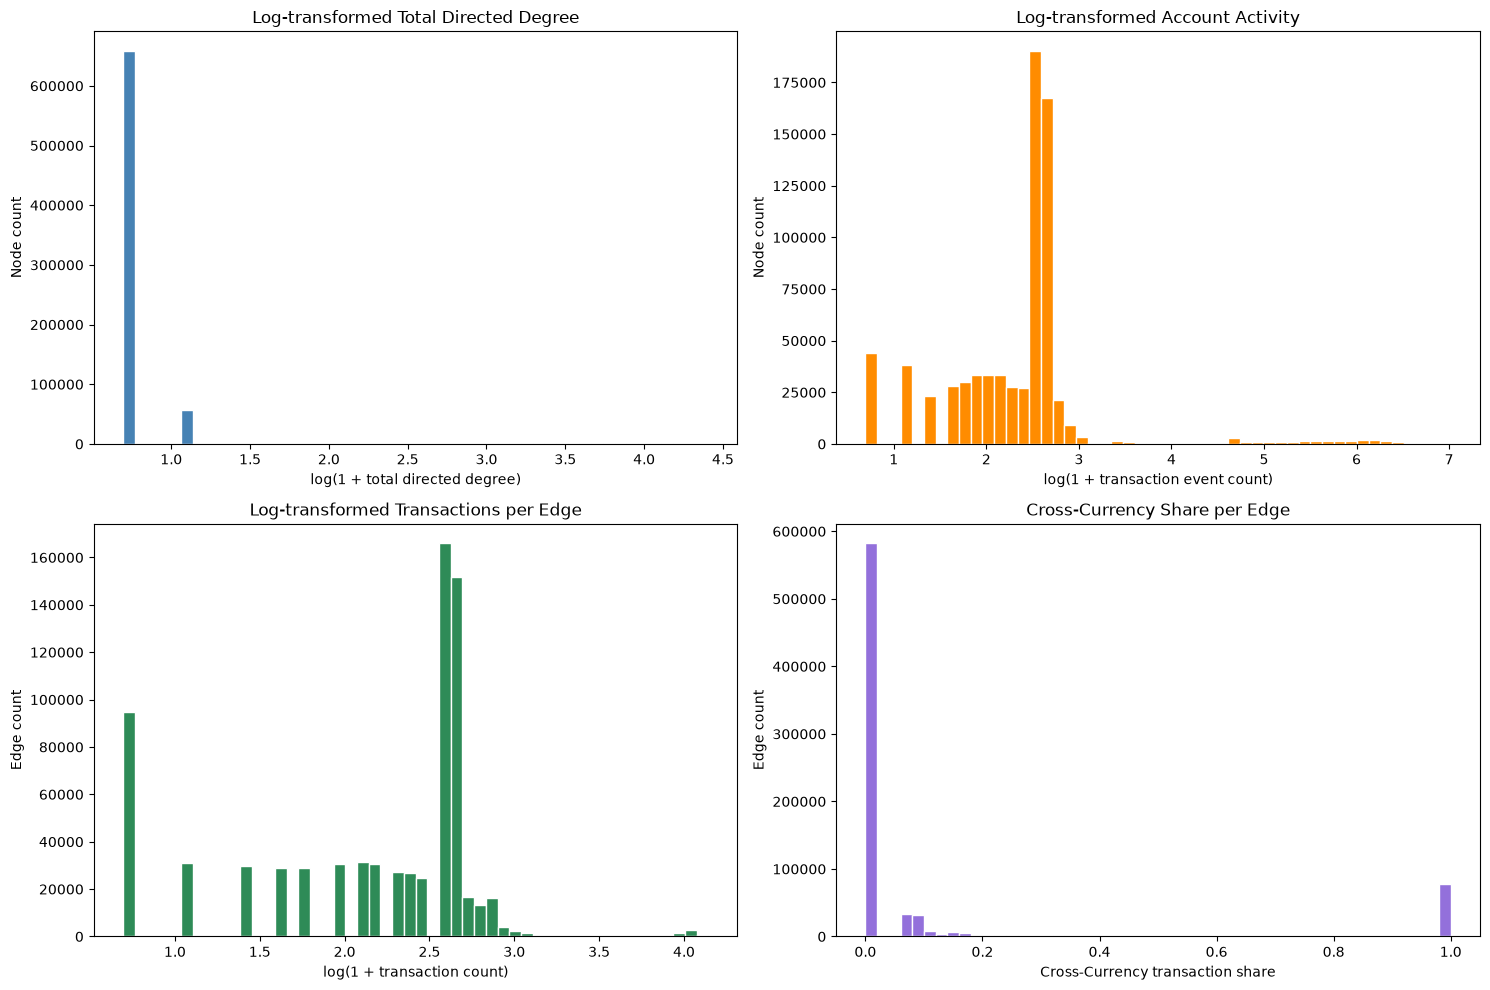

In [8]:
### visualize skewed node and edge distributions
# node data
node_plot_data = (
    graph_eda.nodes
    .select(
        [
            'total_directed_degree',
            'account_transaction_event_count'
        ]
    )
    .collect(
        engine = 'streaming'
    )
)

# edge data
edge_plot_data = (
    graph_eda.edges
    .select(
        [
            'transaction_count',
            'cross_currency_share'
        ]
    )
    .collect(
        engine = 'streaming'
    )
)

fig, axes = plt.subplots(
    nrows = 2,
    ncols = 2,
    figsize = (15, 10)
)

axes[0, 0].hist(
    np.log1p(
        node_plot_data['total_directed_degree'].to_numpy()
    ),
    bins = 50,
    color = 'steelblue',
    edgecolor = 'white'
)
axes[0, 0].set_title('Log-transformed Total Directed Degree')
axes[0, 0].set_xlabel('log(1 + total directed degree)')
axes[0, 0].set_ylabel('Node count')

axes[0, 1].hist(
    np.log1p(
        node_plot_data['account_transaction_event_count'].to_numpy()        
    ),
    bins = 50,
    color = 'darkorange',
    edgecolor = 'white'
)
axes[0, 1].set_title('Log-transformed Account Activity')
axes[0, 1].set_xlabel('log(1 + transaction event count)')
axes[0, 1].set_ylabel('Node count')

axes[1, 0].hist(
    np.log1p(
        edge_plot_data['transaction_count'].to_numpy()
    ),
    bins = 50,
    color = 'seagreen',
    edgecolor = 'white'
)
axes[1, 0].set_title('Log-transformed Transactions per Edge')
axes[1, 0].set_xlabel('log(1 + transaction count)')
axes[1, 0].set_ylabel('Edge count')

axes[1, 1].hist(
    edge_plot_data['cross_currency_share'].to_numpy(),
    bins = 50,
    color = 'mediumpurple',
    edgecolor = 'white'
)
axes[1, 1].set_title('Cross-Currency Share per Edge')
axes[1, 1].set_xlabel('Cross-Currency transaction share')
axes[1, 1].set_ylabel('Edge count')

fig.tight_layout()
plt.show()

In [9]:
### Full-network topology with igraph
# materialize validation graph in igraph
validation_graph = graph_eda.build_igraph()

print(
    f'Directed graph: {validation_graph.is_directed()}'
)
print(
    f'Vertices: {validation_graph.vcount():,}'
)
print(
    f'Edges: {validation_graph.ecount():,}'
)
print(
    f'Edge attributes: {validation_graph.es.attribute_names()}'
)

Directed graph: True
Vertices: 736,925
Edges: 761,365
Edge attributes: ['count_weight', 'log_count_weight']


In [10]:
### directed connectivity summary
validation_connectivity_summary = graph_eda.get_connectivity_summary()

display(
    validation_connectivity_summary
    .row(
        index = 0, 
        named = True
    )
)

{'node_count': 736925,
 'edge_count': 761365,
 'density': 1.4019964614858901e-06,
 'reciprocity': 0.10837377604696827,
 'mean_in_degree': 1.0331648403840281,
 'mean_out_degree': 1.0331648403840281,
 'isolated_node_count': 0,
 'receiver_only_node_count': 500031,
 'sender_only_node_count': 158717,
 'weak_component_count': 17340,
 'largest_weak_component_size': 632,
 'largest_weak_component_share': 0.0008576178037113682,
 'strong_component_count': 695434,
 'largest_strong_component_size': 29,
 'largest_strong_component_share': 3.935271567662924e-05}

In [11]:
### largest weak and strong components
largest_weak_components = graph_eda.get_component_size_summary(
    mode = 'weak',
    top_n = 15
)

largest_strong_components = graph_eda.get_component_size_summary(
    mode = 'strong',
    top_n = 15
)

with pl.Config(
    tbl_rows = -1
):
    display(largest_weak_components)
    display(largest_strong_components)

component_mode,component_rank,component_size,node_share,cumulative_node_share
str,i64,i64,f64,f64
"""weak""",1,632,0.000858,0.000858
"""weak""",2,618,0.000839,0.001696
"""weak""",3,586,0.000795,0.002491
"""weak""",4,552,0.000749,0.00324
"""weak""",5,534,0.000725,0.003965
"""weak""",6,512,0.000695,0.00466
"""weak""",7,509,0.000691,0.005351
"""weak""",8,497,0.000674,0.006025
"""weak""",9,484,0.000657,0.006682


component_mode,component_rank,component_size,node_share,cumulative_node_share
str,i64,i64,f64,f64
"""strong""",1,29,0.000039,0.000039
"""strong""",2,29,0.000039,0.000079
"""strong""",3,25,0.000034,0.000113
"""strong""",4,25,0.000034,0.000147
"""strong""",5,24,0.000033,0.000179
"""strong""",6,23,0.000031,0.00021
"""strong""",7,23,0.000031,0.000242
"""strong""",8,22,0.00003,0.000271
"""strong""",9,22,0.00003,0.000301


**Discussion - fragmentation, reciprocity and reachability**

The density of approximately $1.40 * 10^{-6}$ confirms that the network is extremely sparse. Recipricity is only **10.84%**, so most account relationshipsdo not have a reverse edge during the historical window

The network is also highly fragmented. It contains **17340 wakly connected components**, the largest has only **632 nodes (0.0858%)**, and even the 15 largest weak components together contain just 1.04% of all nodes. We therefore can safely conclude that there is no giant connected component

Directed connectivity is weaker still; there are **695k strongly connected components**, and the largest contains only **29 nodes**. Because a non-trivial strongly connected component requires directed return paths, this result indicates that cycles and mutually reachable flow structures are small relative to the entire network

This has an important consequence for Personalized PageRank; being present in the historical graph makes a target rankable, but does not guarantee that it is reachable from a historical seed. Before interpreting Personalized PageRank performance, we should measure:
- how many candidates and targets share a weak component with at least one seed
- how many targets are directionally reachable from seeds in the forward graph
- how many become reachable when transaction direction is reversed

Ordinary PageRank can assign scores throughout the graph through uniform teleportation; whereas seed-personalized propagation will depend much more heavily on this component and reachability structure

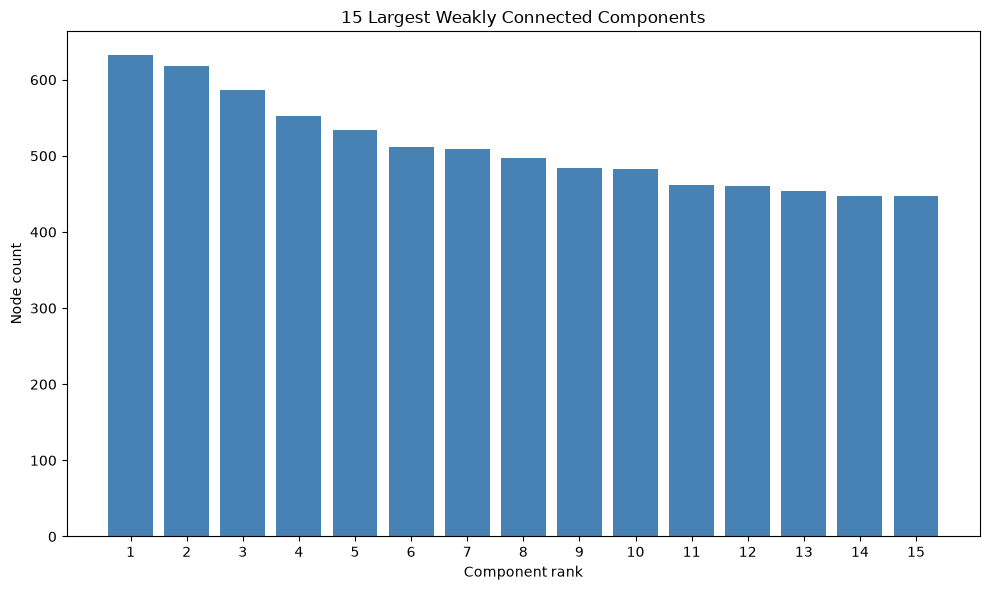

In [12]:
### visualize largest weak components
fig, ax = plt.subplots(figsize = (10, 6))

ax.bar(
    largest_weak_components['component_rank'].to_numpy(),
    largest_weak_components['component_size'].to_numpy(),
    color = 'steelblue'
)
ax.set_title('15 Largest Weakly Connected Components')
ax.set_xlabel('Component rank')
ax.set_ylabel('Node count')
ax.set_xticks(
    largest_weak_components['component_rank'].to_numpy()
)

fig.tight_layout()
plt.show()

In [13]:
### compare seeds, rankable targets and other candidates
population_structural_summary = graph_eda.get_population_structural_summary()

with pl.Config(
    tbl_cols = -1
):
    display(population_structural_summary)

population,node_count,mean_transaction_event_count,mean_total_directed_degree,median_total_directed_degree,p95_total_directed_degree,sender_and_receiver_share,receiver_only_share,sender_only_share,multi_location_share
str,u64,f64,f64,f64,f64,f64,f64,f64,f64
"""historical_seed""",5737,142.003835,16.678229,17.0,34.0,0.88426,0.086631,0.029109,0.233223
"""rankable_validation_target""",678,155.758112,15.513274,16.0,30.0,0.924779,0.0059,0.069322,0.100295
"""other_candidate""",730510,18.038488,1.939096,1.0,2.0,0.099214,0.68381,0.216976,0.00538


**Discussion - structural signal in suspicious populations**

Historical seeds and future rankable targets are structurally very different from other candidates:
- Historical seeds average **142.0 transaction events** and future targets **155.8**, compared with **18.0** for other candidates; aapproximately **8x higher**
- Their mean total degrees are **16.68** and **15.51**, compared **1.94** for other candidates; approximately **8x higher**
- About **88.4%** of seeds and **92.5%** of rankable targets both sender and receiver, compared with only **9.9%** of other candidates. This is consistent with suspicious accounts frequently acting as intermediaries rather than transaction endpoints
- Multi-location activity appears for **23.32%** of seeds and **10.03%** of future targets, but only **0.54%** of other candidates

These differences provide strong evidence that historical graph structure contains useful predictive signal. They also mean that PageRank must be compared with sample degree, activity, and node-role baselines; if a basic degree ranking performs similarly, PageRank has not yet demonstrated incremental value. Due to using synthetic banking dataset, the unusually strong separation may partly reflect how laundering typologies were generated and should be stated as a limitation

In [14]:
### inspect highest-degree account hubs
top_out_degree_nodes = graph_eda.get_top_nodes(
    metric = 'out_degree',
    top_n = 15
)

top_in_degree_nodes = graph_eda.get_top_nodes(
    metric = 'in_degree',
    top_n = 15
)

top_total_degree_nodes = graph_eda.get_top_nodes(
    metric = 'total_directed_degree',
    top_n = 15
)

with pl.Config(
    tbl_rows = -1
):
    print('Top out-degree nodes')
    display(top_out_degree_nodes)

    print('Top in-degree nodes')
    display(top_in_degree_nodes)

    print('Top total-degree nodes')
    display(top_total_degree_nodes)

Top out-degree nodes


node_id,account,out_degree,in_degree,total_directed_degree,outgoing_transaction_count,incoming_transaction_count,population
u64,str,u64,u64,u64,u64,u64,str
149508,"""2822872306""",59,5,64,533,24,"""other_candidate"""
576062,"""8035399972""",59,13,72,590,128,"""other_candidate"""
6823,"""108321125""",58,20,78,585,213,"""other_candidate"""
44209,"""1542389688""",58,10,68,521,105,"""other_candidate"""
260836,"""4179671957""",58,2,60,562,6,"""other_candidate"""
336157,"""5097207315""",58,3,61,521,16,"""other_candidate"""
515303,"""7288416542""",58,2,60,530,4,"""other_candidate"""
571631,"""798082205""",58,4,62,616,16,"""other_candidate"""
24328,"""1298080955""",57,22,79,598,214,"""other_candidate"""


Top in-degree nodes


node_id,account,in_degree,out_degree,total_directed_degree,outgoing_transaction_count,incoming_transaction_count,population
u64,str,u64,u64,u64,u64,u64,str
53138,"""1652013105""",41,3,44,3,271,"""historical_seed"""
201885,"""3458503586""",41,3,44,9,272,"""historical_seed"""
561770,"""7859972869""",39,2,41,6,45,"""historical_seed"""
302686,"""4689351304""",38,4,42,12,248,"""historical_seed"""
663600,"""9101431692""",38,1,39,7,159,"""historical_seed"""
54225,"""1665774528""",37,19,56,227,38,"""historical_seed"""
554607,"""7772352930""",37,3,40,6,224,"""historical_seed"""
619173,"""8558866681""",36,4,40,16,43,"""historical_seed"""
569218,"""7951108994""",35,2,37,5,139,"""historical_seed"""


Top total-degree nodes


node_id,account,total_directed_degree,out_degree,in_degree,outgoing_transaction_count,incoming_transaction_count,population
u64,str,u64,u64,u64,u64,u64,str
527631,"""7440281227""",81,57,24,495,251,"""other_candidate"""
552109,"""7742283519""",81,57,24,517,216,"""other_candidate"""
336090,"""5096449545""",80,55,25,510,253,"""other_candidate"""
24328,"""1298080955""",79,57,22,598,214,"""other_candidate"""
129800,"""2580810242""",79,55,24,540,264,"""other_candidate"""
249437,"""4039273849""",79,57,22,540,233,"""other_candidate"""
487039,"""6940226374""",79,56,23,515,257,"""other_candidate"""
601264,"""8340937716""",79,55,24,520,248,"""other_candidate"""
662467,"""9087184809""",79,54,25,572,264,"""other_candidate"""


**Discussion - implications of the highest-degree hubs**

All 15 displayed top out-degree and top total-degree accounts are labelled as **other_candidate**. This label means that they are neither historical seeds nor rankable validation targets; it does not prove that they are permanently legitimate. Nevertheless, high connectivity alone promotes many non-target operational hubs and may produce false positives in the current validation window

In contrast, all 15 displayed top in-degree accounts are historical seeds. This suggests that known laundering accounts frequently behave as aggregation or fan-in nodes. Forward PageRank may capture this behavior, but it may primarily rediscover known seeds, which must be removed before candidate evaluation

| Ranking | Main purpose |
|---|---|
| Total degree and transaction activity | Non-PageRank reference baselines |
| Forward PageRank | Identify accounts receiving importance from influential senders |
| Reverse PageRank | Trace influential funding or distribution sources |
| Count-weighted PageRank | Use repeated transaction frequency directly |
| Log-count-weighted PageRank | Retain frequency information while limiting dominant edges |
| Personalized PageRank | Propagate risk specifically from historical suspicious seeds |

Ordinary PageRank should therefore be treated as a centrality benchmark, not as a complete fraud-ring detector